# Week 7: ANOVA: 빈도주의 vs 베이지안

## 학습 목표 (Learning Objectives)

1.  **ANOVA의 개발 목적 (Purpose of ANOVA)**:
    *   **ANOVA (Analysis of Variance, 분산 분석)**는 **세 개 이상의 집단 평균**을 동시에 비교하기 위해 R.A. Fisher에 의해 개발되었습니다. (Developed by R.A. Fisher to compare means of **three or more groups** simultaneously.)
    *   **다중 검정 문제 해결**: 만약 3개 집단을 비교하기 위해 t-test를 세 번(A-B, B-C, A-C) 수행하면, 우연히 차이가 있다고 결론 내릴 확률(**제1종 오류, Type I Error**)이 급격히 증가합니다.
    *   ANOVA는 집단 간의 분산(Between-group variance)과 집단 내의 분산(Within-group variance)의 비율(F-ratio)을 분석하여, **오류율을 증가시키지 않고 단 한 번의(omnibus) 분석으로** 집단 간 차이 여부를 평가합니다.
    *   *If we perform multiple t-tests, the Type I error rate increases. ANOVA addresses this by analyzing the ratio of between-group variance to within-group variance, providing a single omnibus assessment without inflating the error rate.*

2.  **베이지안 ANOVA 해석이 빈도주의 ANOVA와 다른 점 (How Bayesian ANOVA differs from Frequentist ANOVA)**:

    **(1) 질문 자체가 다름 (Different question)**
    *   **빈도주의(Frequentist)**: “$H_0(\mu_A=\mu_B=\mu_C)$가 참이라고 가정할 때, 관측된 F(또는 그보다 더 극단적인 값)가 나올 확률은?” → p-value는 $P(\text{data} \mid H_0)$ 형태입니다.
    *   **베이지안(Bayesian)**: “데이터를 본 후, 각 평균과 평균 차이(대비; contrasts)는 어떤 값일 가능성이 큰가?” → 사후분포는 $P(\theta \mid \text{data})$ 형태입니다.

    **(2) 결과 표현 방식이 다름 (Different outputs and interpretation)**
    *   **빈도주의**: 보통 “전체적으로 그룹 평균이 동일하다고 보기 어렵다/어렵지 않다”처럼 **가설 검정 관점의 결론**을 제공합니다. 또한 어느 그룹이 다른지는 별도의 사후검정(post-hoc; Tukey 등)이 필요합니다.
    *   **베이지안**: 각 그룹 평균($\mu_A,\mu_B,\mu_C$)과 대비(예: $\mu_B-\mu_A$)에 대한 **사후 분포**를 직접 제공합니다.
        *   예: $P(\mu_B-\mu_A > 0 \mid \text{data}) = 0.95$ 처럼 “B가 A보다 클 확률”을 직접 말할 수 있습니다.
        *   구간도 “신뢰구간(confidence interval)”이 아니라 “신용구간/credible interval(또는 HDI)”로 해석합니다: “모수가 이 구간에 있을 사후확률이 96%”처럼 해석 가능.

    **(3) 다중비교 관점이 다름 (Multiple comparisons framing)**
    *   **빈도주의**: 여러 쌍 비교를 하면 오류율(Type I error) 통제가 핵심 이슈가 되어 보정이 중요합니다.
    *   **베이지안**: 여러 대비를 보더라도 각 대비의 사후확률/구간을 보고할 수 있습니다. (단, 결론을 ‘결정’하려면 ROPE 같은 실질적 기준을 함께 두는 것이 일반적입니다.)

    **English (brief)**
    *   **Frequentist ANOVA** asks $P(\text{data} \mid H_0)$ (p-value) and yields an omnibus decision-like statement; pairwise differences are typically addressed via post-hoc tests.
    *   **Bayesian ANOVA** focuses on $P(\theta \mid \text{data})$: posterior distributions for group means and contrasts, enabling direct probability statements (e.g., $P(\mu_B-\mu_A>0\mid\text{data})$) and credible intervals/HDIs interpreted as posterior mass.

## 이론적 배경 (Mathematical Background)

F-statistic for ANOVA:  
$$ F = \frac{\text{Between-group variance}}{\text{Within-group variance}} $$

## 데이터 시뮬레이션 (Data Simulation)
Python을 사용하여 가상의 데이터를 생성합니다.

In [15]:
import pandas as pd
import numpy as np

# 3개 그룹 데이터 생성
data = {
    'Score': np.concatenate([np.random.normal(10, 2, 30), np.random.normal(12, 2, 30), np.random.normal(11, 2, 30)]),
    'Group': ['A']*30 + ['B']*30 + ['C']*30
}
df = pd.DataFrame(data)

## 결과 시뮬레이션 및 가시화 (Visualization)
생성된 데이터 또는 분석 결과를 시각화합니다.

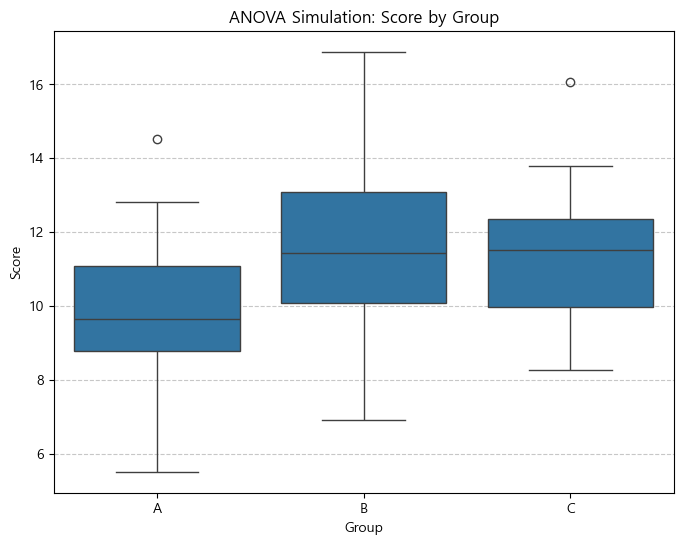

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='Score', data=df)
plt.title('ANOVA Simulation: Score by Group')

# 가로 그리드 라인 추가 (Add horizontal grid lines)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

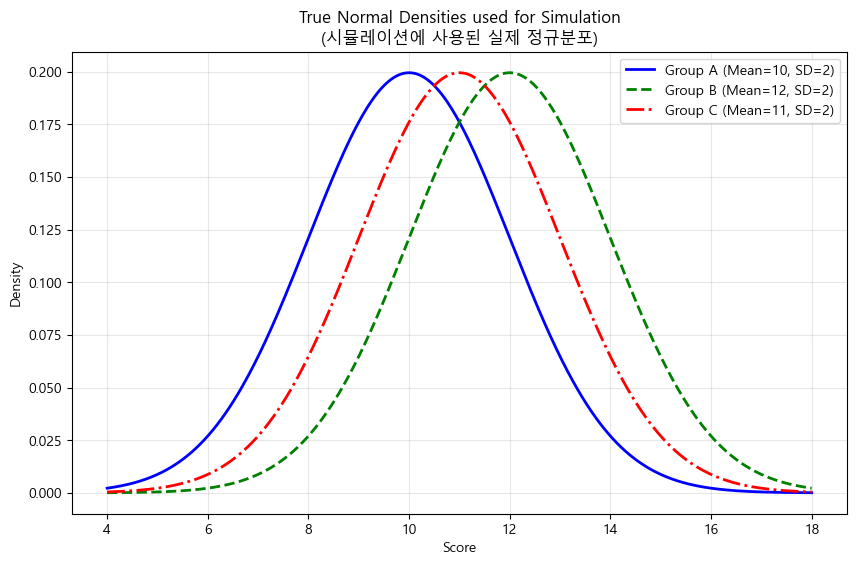

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import platform

# 한글 폰트 설정 (Korean Font Configuration)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지 (Prevent minus sign corruption)
plt.rcParams['axes.unicode_minus'] = False

# x축 범위 설정 (Set x-axis range)
# 평균들을 중심으로 충분한 범위를 잡습니다 (Covering +/- 3~4 SD)
x = np.linspace(4, 18, 500)

# 3개 그룹의 확률밀도함수 (PDFs for 3 groups)
# Group A: Mean=10, SD=2
pdf_a = norm.pdf(x, 10, 2)
# Group B: Mean=12, SD=2
pdf_b = norm.pdf(x, 12, 2)
# Group C: Mean=11, SD=2
pdf_c = norm.pdf(x, 11, 2)

plt.figure(figsize=(10, 6))

# 각 그룹의 PDF 그리기 (Plot PDF for each group)
plt.plot(x, pdf_a, label='Group A (Mean=10, SD=2)', color='blue', linewidth=2)
plt.plot(x, pdf_b, label='Group B (Mean=12, SD=2)', color='green', linewidth=2, linestyle='--')
plt.plot(x, pdf_c, label='Group C (Mean=11, SD=2)', color='red', linewidth=2, linestyle='-.')

plt.title('True Normal Densities used for Simulation\n(시뮬레이션에 사용된 실제 정규분포)')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
import numpy as np
from scipy import stats

# Frequentist one-way ANOVA (빈도주의 일원분산분석)
# H0: mu_A = mu_B = mu_C

# 그룹별 데이터 분리 (Split data by group)
groups = sorted(df['Group'].unique())
values_by_group = [df.loc[df['Group'] == g, 'Score'].to_numpy() for g in groups]

# 1) scipy ANOVA: F and p-value
F_stat, p_value = stats.f_oneway(*values_by_group)

# 2) ANOVA table quantities (SS, df, MS)
all_values = df['Score'].to_numpy()
overall_mean = all_values.mean()

n_by_group = np.array([len(v) for v in values_by_group])
means_by_group = np.array([v.mean() for v in values_by_group])
vars_by_group = np.array([v.var(ddof=1) for v in values_by_group])

k = len(groups)
N = len(all_values)

df_between = k - 1
# within (error) degrees of freedom
# df_within = sum_i (n_i - 1) = N - k
# total df = N - 1

df_within = N - k

df_total = N - 1

# Sum of Squares Between (SSB): sum_i n_i (mean_i - overall_mean)^2
SS_between = np.sum(n_by_group * (means_by_group - overall_mean) ** 2)

# Sum of Squares Within (SSW): sum_i sum_j (y_ij - mean_i)^2
SS_within = np.sum([np.sum((v - v.mean()) ** 2) for v in values_by_group])

# Total Sum of Squares (SST) = sum_j (y_j - overall_mean)^2
SS_total = np.sum((all_values - overall_mean) ** 2)

MS_between = SS_between / df_between
MS_within = SS_within / df_within

F_from_MS = MS_between / MS_within

print("=== One-way ANOVA (Frequentist) ===")
print(f"Groups: {groups}")
print(f"N per group: {dict(zip(groups, n_by_group))}")
print(f"Group means: {dict(zip(groups, np.round(means_by_group, 3)))}")
print(f"Overall mean: {overall_mean:.3f}")
print("-")
print(f"SS_between (SSB): {SS_between:.4f}")
print(f"SS_within  (SSW): {SS_within:.4f}")
print(f"SS_total   (SST): {SS_total:.4f}  (check: SSB+SSW={SS_between+SS_within:.4f})")
print("-")
print(f"df_between: {df_between}")
print(f"df_within : {df_within}")
print(f"df_total  : {df_total}")
print("-")
print(f"MS_between: {MS_between:.6f}")
print(f"MS_within : {MS_within:.6f}")
print("-")
print(f"F (scipy): {F_stat:.6f}")
print(f"F (MS ratio): {F_from_MS:.6f}")
print(f"p-value: {p_value:.6g}")

=== One-way ANOVA (Frequentist) ===
Groups: ['A', 'B', 'C']
N per group: {'A': 30, 'B': 30, 'C': 30}
Group means: {'A': 9.919, 'B': 11.567, 'C': 11.268}
Overall mean: 10.918
-
SS_between (SSB): 46.2297
SS_within  (SSW): 327.8819
SS_total   (SST): 374.1116  (check: SSB+SSW=374.1116)
-
df_between: 2
df_within : 87
df_total  : 89
-
MS_between: 23.114868
MS_within : 3.768757
-
F (scipy): 6.133286
F (MS ratio): 6.133286
p-value: 0.00322223


## 빈도주의 ANOVA 출력 해석 (Interpreting Frequentist ANOVA Outputs)

### 핵심 아이디어 (Key Idea)
일원분산분석(One-way ANOVA)은 **집단 간 평균 차이**가 “집단 내 변동(오차)”에 비해 충분히 큰지 비교합니다.
One-way ANOVA compares whether the **between-group mean differences** are large relative to the **within-group variability (error)**.

---

### 출력량 설명 (Quantities Explained)

- **SS_between (SSB, 집단 간 제곱합)**
  - 각 집단 평균이 전체 평균에서 얼마나 떨어져 있는지(그리고 표본 수로 가중됨)를 측정합니다.
  - Measures how far each group mean is from the overall mean (weighted by group sizes).

- **SS_within (SSW, 집단 내 제곱합 / 오차 제곱합)**
  - 각 집단 내부에서 점수들이 집단 평균 주변에 얼마나 퍼져 있는지(오차 변동)를 측정합니다.
  - Measures how dispersed observations are around their own group mean (error variability).

- **SS_total (SST, 전체 제곱합)**
  - 전체 데이터가 전체 평균 주변에 얼마나 퍼져 있는지입니다.
  - Satisfies: $SST = SSB + SSW$ (수치적으로 거의 같아야 정상).
  - Measures overall variability around the grand mean, with $SST = SSB + SSW$.

- **df_between (집단 간 자유도)**
  - $k-1$ (k = 그룹 수). 그룹 평균을 몇 개 독립적으로 비교하는지에 해당합니다.
  - $k-1$ where $k$ is the number of groups.

- **df_within (집단 내 자유도)**
  - $N-k$ (N = 전체 표본 수). 오차(집단 내부 변동)를 추정하는 데 사용됩니다.
  - $N-k$ where $N$ is the total sample size.

- **MS_between (집단 간 평균제곱)**
  - $MSB = SSB / df_{between}$. 집단 간 변동의 “평균” 크기입니다.
  - $MSB = SSB / df_{between}$.

- **MS_within (집단 내 평균제곱 / 오차분산 추정치)**
  - $MSW = SSW / df_{within}$. 오차 분산(공통 분산)의 추정치로 해석됩니다.
  - $MSW = SSW / df_{within}$; often interpreted as an estimate of the common error variance.

- **F 통계량 (F-statistic)**
  - $F = MSB / MSW$. 즉, “집단 간 변동”이 “집단 내 변동”보다 얼마나 큰지의 비율입니다.
  - Large $F$ suggests group means are more separated relative to within-group noise.

- **p-value**
  - $H_0: \mu_A=\mu_B=\mu_C$ (모든 평균이 같다)가 참일 때, 관측된 F 이상이 나올 확률입니다.
  - 작을수록(예: 0.05 미만) “전체적으로 평균이 동일하다는 가정이 데이터와 잘 맞지 않는다”는 방향의 증거로 해석합니다.
  - Under $H_0$, probability of observing an F as extreme or more; smaller values indicate the data are less compatible with equal means.

> 참고: ANOVA가 ‘전체적으로’ 차이를 암시하더라도, 어떤 쌍이 다른지는 **사후검정(post-hoc)** 또는 **대비(contrast)** 분석이 필요합니다.
> Note: Even if ANOVA suggests differences overall, identifying which pairs differ requires post-hoc tests or contrasts.

## 베이지안 ANOVA (Bayesian One-way ANOVA with Stan/CmdStanPy)

### 핵심 해석 차이 (Key interpretational difference)
- **빈도주의 ANOVA**는 주로 p-value를 통해 “모든 평균이 같다”라는 가정이 데이터와 얼마나 잘 맞는지(compatibility)를 평가합니다.
- **베이지안 ANOVA**는 각 그룹 평균과 그룹 간 차이(contrast)에 대한 **사후 분포(posterior distribution)**를 추정하여,
  “$\mu_B-\mu_A$가 0보다 클 확률”처럼 **확률 진술(probability statements)**을 직접 제공합니다.

- **Frequentist ANOVA** typically uses a p-value to assess how compatible the data are with the equal-means assumption.
- **Bayesian ANOVA** estimates posterior distributions for group means and contrasts, enabling direct probability statements such as
  “$P(\mu_B-\mu_A>0\mid\text{data})$.”

### 왜 계층모형(hierarchical model)로 베이지안 ANOVA를 구성했나요? (Why a hierarchical model for Bayesian ANOVA?)

일원분산분석(One-way ANOVA)은 본질적으로 “총 변동을 **집단 간(between)**과 **집단 내(within)** 변동으로 분해해서” 집단 평균 차이를 평가합니다.  
A one-way ANOVA is fundamentally about decomposing variability into **between-group** and **within-group** components.

베이지안에서는 이 아이디어를 **생성모형(generative model)**으로 자연스럽게 표현할 수 있어서 계층모형을 사용했습니다:
- 관측치: $y_{n} \sim \mathcal{N}(\mu_{g[n]},\,\sigma)$  (집단 내 변동: $\sigma$)
- 집단 평균: $\mu_k = \mu_0 + \alpha_k$, 그리고 $\alpha_k \sim \mathcal{N}(0,\,\tau)$  (집단 간 변동: $\tau$)

이렇게 하면 얻는 장점이 있습니다 (Key benefits):
1. **ANOVA와 같은 분산 성분 해석**: $\sigma$는 집단 내, $\tau$는 집단 간 변동을 직접 나타내며, ICC 같은 요약도 바로 계산됩니다.
2. **부분 풀링(partial pooling)**: 각 집단 평균 추정이 ‘완전 분리(no pooling)’와 ‘완전 통합(complete pooling)’의 중간이 되어, 표본이 작거나 노이즈가 큰 집단에서 과도한 추정을 완화합니다.
3. **불균형 표본/결측에 강함**: 집단별 표본 수가 달라도(또는 일부 결측이 있어도) 동일한 구조로 추정이 가능합니다.
4. **예측/진단(PPC)까지 한 번에**: 평균 차이뿐 아니라 “모형이 데이터를 잘 재현하는가”를 PPC로 점검하는 흐름이 자연스럽습니다.

요약하면, 계층모형은 ANOVA의 핵심(집단 간 vs 집단 내 변동)을 베이지안 방식으로 가장 직접적이고 해석 가능하게 구현하면서, **부분 풀링**이라는 실용적인 이점을 제공하기 때문에 선택했습니다.

---

### 참고 자료 / 튜토리얼 (References & Tutorials)

- Stan User’s Guide — Hierarchical / Multilevel models: https://mc-stan.org/docs/stan-users-guide/hierarchical-models.html
- Stan User’s Guide — Prior choice recommendations: https://github.com/stan-dev/stan/wiki/Prior-Choice-Recommendations
- CmdStanPy documentation (how to compile & sample in Python): https://mc-stan.org/cmdstanpy/
- Gelman, Hill — *Data Analysis Using Regression and Multilevel/Hierarchical Models* (multilevel modeling classic): http://www.stat.columbia.edu/~gelman/arm/
- Gelman et al. — *Bayesian Data Analysis* (free draft + materials): http://www.stat.columbia.edu/~gelman/book/
- McElreath — *Statistical Rethinking* (multilevel + Bayesian workflow, very tutorial-style): https://xcelab.net/rm/statistical-rethinking/
- Posterior predictive checks (PPC) overview (Gelman): http://www.stat.columbia.edu/~gelman/research/published/p753.pdf

14:25:39 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bayes_anova_oneway.stan to exe file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bayes_anova_oneway.exe


Stan model saved to: bayes_anova_oneway.stan


14:25:49 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\bayes_anova_oneway.exe
14:25:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

14:25:50 - cmdstanpy - INFO - CmdStan done processing.




=== Bayesian ANOVA (Posterior summaries) ===
Groups: ['A', 'B', 'C']
Posterior sigma (within SD) mean: 1.972, 96% HDI: (1.680200342, 2.308252756)
Posterior tau   (group SD)  mean: 1.818, 96% HDI: (0.2950106622000003, 6.269977619999999)

Posterior group means (mu_k):
- A: mean=10.094, 96% HDI=[7.129, 13.502]
- B: mean=11.542, 96% HDI=[8.730, 15.175]
- C: mean=11.274, 96% HDI=[8.439, 14.825]

Posterior pairwise differences P(mu_i - mu_j > 0):
- A-B: P(>0)=0.004, mean=-1.448, 96% HDI=[-2.549, -0.276]
- A-C: P(>0)=0.015, mean=-1.181, 96% HDI=[-2.278, -0.091]
- B-A: P(>0)=0.997, mean=1.448, 96% HDI=[0.276, 2.549]
- B-C: P(>0)=0.716, mean=0.268, 96% HDI=[-0.759, 1.285]
- C-A: P(>0)=0.986, mean=1.181, 96% HDI=[0.091, 2.278]
- C-B: P(>0)=0.284, mean=-0.268, 96% HDI=[-1.285, 0.759]


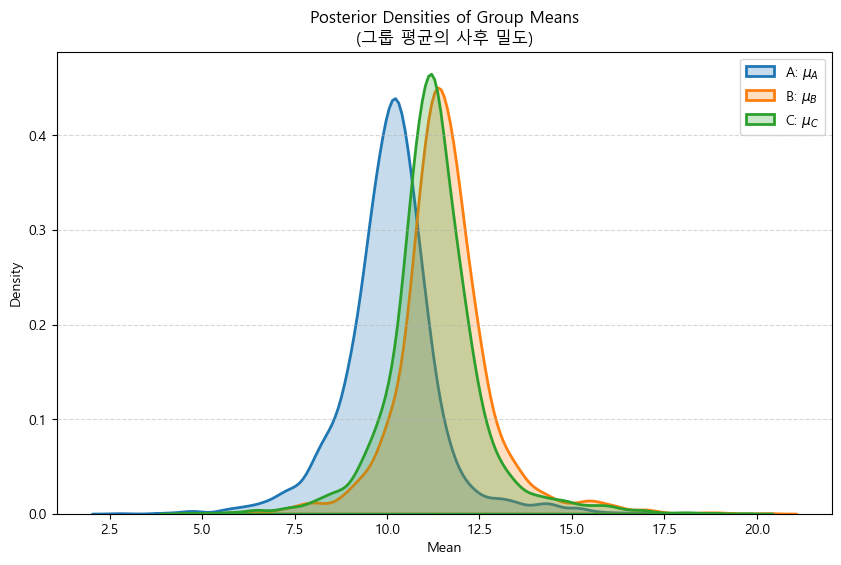

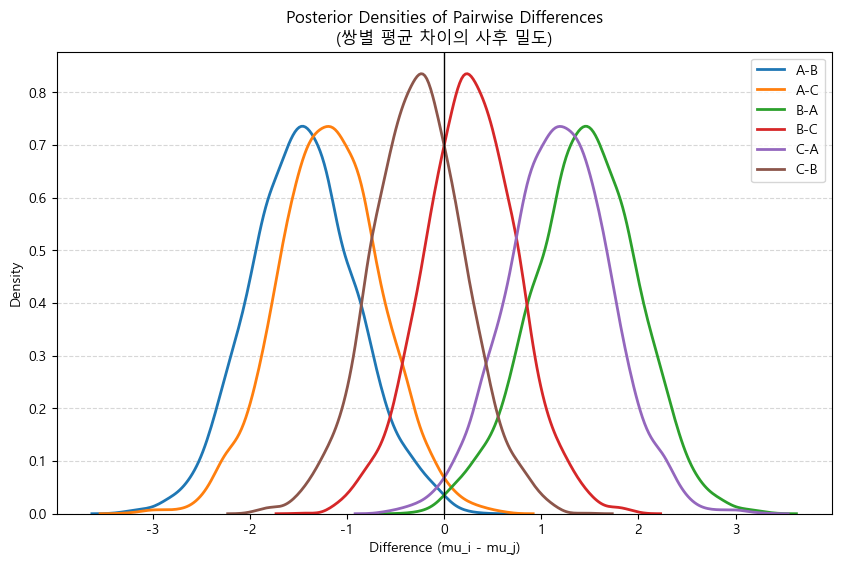

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

from cmdstanpy import CmdStanModel

# 한글 폰트 설정 (Korean Font Configuration)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# 1) Data prep (데이터 준비)
# -----------------------------
# 그룹을 1..K 인덱스로 변환 (Map groups to 1..K)
groups_sorted = sorted(df['Group'].unique())
group_to_idx = {g: i + 1 for i, g in enumerate(groups_sorted)}

y = df['Score'].to_numpy().astype(float)
g = df['Group'].map(group_to_idx).to_numpy().astype(int)

N = len(y)
K = len(groups_sorted)

stan_data = {
    'N': N,
    'K': K,
    'y': y,
    'g': g
}

# -----------------------------
# 2) Stan model (모형 정의)
# -----------------------------
# One-way ANOVA as a hierarchical normal model:
# y_n ~ Normal(mu_g[n], sigma)
# mu_k = mu0 + alpha_k, alpha_k ~ Normal(0, tau)

stan_code = r"""
data {
  int<lower=1> N;
  int<lower=1> K;
  vector[N] y;
  array[N] int<lower=1, upper=K> g;
}
parameters {
  real mu0;
  vector[K] alpha;     // group effects (mean deviations)
  real<lower=0> sigma; // within-group SD
  real<lower=0> tau;   // group-level SD
}
transformed parameters {
  vector[K] mu;
  mu = mu0 + alpha;
}
model {
  // Priors (weakly informative)
  mu0 ~ normal(mean(y), 10);
  alpha ~ normal(0, tau);
  tau ~ normal(0, 5);   // half-normal due to <lower=0>
  sigma ~ normal(0, 5); // half-normal due to <lower=0>

  // Likelihood
  for (n in 1:N) {
    y[n] ~ normal(mu[g[n]], sigma);
  }
}
generated quantities {
  vector[K] mu_centered;
  vector[K] alpha_centered;
  vector[K] mu_out;
  matrix[K, K] diff;

  // Centered versions are often easier to interpret
  alpha_centered = alpha - mean(alpha);
  mu_centered = mu0 + alpha_centered;

  // Also keep the raw mu
  mu_out = mu;

  // Pairwise differences
  for (i in 1:K) {
    for (j in 1:K) {
      diff[i, j] = mu_centered[i] - mu_centered[j];
    }
  }
}
"""

stan_file = 'bayes_anova_oneway.stan'
with open(stan_file, 'w', encoding='utf-8') as f:
    f.write(stan_code)

print(f"Stan model saved to: {stan_file}")

# -----------------------------
# 3) Compile + sample
# -----------------------------
model = CmdStanModel(stan_file=stan_file)
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

draws = fit.draws_pd()

# Extract posterior samples
# We use centered group means mu_centered[k]
mu_cols = [f"mu_centered[{i}]" for i in range(1, K+1)]
mu_post = draws[mu_cols].copy()
mu_post.columns = groups_sorted

sigma_post = draws['sigma']
tau_post = draws['tau']

# Pairwise differences (mu_i - mu_j)
# Stan saved diff[i,j] as 'diff[i,j]'
diff_samples = {}
for i, gi in enumerate(groups_sorted, start=1):
    for j, gj in enumerate(groups_sorted, start=1):
        if i == j:
            continue
        key = f"{gi}-{gj}"
        diff_samples[key] = draws[f"diff[{i},{j}]"].to_numpy()

# -----------------------------
# 4) Print posterior summaries
# -----------------------------

def hdi(x, prob=0.96):
    lo = np.percentile(x, (1 - prob) / 2 * 100)
    hi = np.percentile(x, (1 - (1 - prob) / 2) * 100)
    return lo, hi

hdi_prob = 0.96

print("\n=== Bayesian ANOVA (Posterior summaries) ===")
print(f"Groups: {groups_sorted}")
print(f"Posterior sigma (within SD) mean: {sigma_post.mean():.3f}, {int(hdi_prob*100)}% HDI: {hdi(sigma_post, hdi_prob)}")
print(f"Posterior tau   (group SD)  mean: {tau_post.mean():.3f}, {int(hdi_prob*100)}% HDI: {hdi(tau_post, hdi_prob)}")

print("\nPosterior group means (mu_k):")
for gname in groups_sorted:
    lo, hi = hdi(mu_post[gname].to_numpy(), hdi_prob)
    print(f"- {gname}: mean={mu_post[gname].mean():.3f}, {int(hdi_prob*100)}% HDI=[{lo:.3f}, {hi:.3f}]")

print("\nPosterior pairwise differences P(mu_i - mu_j > 0):")
for key, arr in diff_samples.items():
    prob_gt0 = (arr > 0).mean()
    lo, hi = hdi(arr, hdi_prob)
    print(f"- {key}: P(>0)={prob_gt0:.3f}, mean={arr.mean():.3f}, {int(hdi_prob*100)}% HDI=[{lo:.3f}, {hi:.3f}]")

# -----------------------------
# 5) Posterior density plots
# -----------------------------
# Plot 1: group mean posteriors
plt.figure(figsize=(10, 6))
for gname in groups_sorted:
    sns.kdeplot(mu_post[gname], fill=True, alpha=0.25, linewidth=2, label=f"{gname}: $\\mu_{gname}$")
plt.title('Posterior Densities of Group Means\n(그룹 평균의 사후 밀도)')
plt.xlabel('Mean')
plt.ylabel('Density')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Plot 2: pairwise difference posteriors (one figure)
plt.figure(figsize=(10, 6))
for key, arr in diff_samples.items():
    sns.kdeplot(arr, fill=False, linewidth=2, label=key)
plt.axvline(0, color='black', linewidth=1)
plt.title('Posterior Densities of Pairwise Differences\n(쌍별 평균 차이의 사후 밀도)')
plt.xlabel('Difference (mu_i - mu_j)')
plt.ylabel('Density')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 사후 분포로 더 보여줄 수 있는 것들 (What else can we show beyond posterior densities?)

차이의 사후 밀도(Posterior density of mean differences)는 매우 직관적이지만, 베이지안 ANOVA에서는 다음과 같은 추가 요약/시각화도 자주 사용합니다.
Posterior densities of mean differences are intuitive, but Bayesian ANOVA often benefits from additional summaries/plots such as:

1. **그룹 평균의 구간 요약(Forest/interval plot)**: 각 그룹 평균의 96% HDI를 한 눈에 비교.
2. **서열/순위 확률(Ordering probabilities)**: 어떤 그룹이 가장 클 확률, 또는 $P(\mu_i > \mu_j)$를 행렬로 표시.
3. **실질적 동등성(ROPE) 확률**: $P(|\mu_i-\mu_j| < \text{ROPE})$ 처럼 “차이가 매우 작을” 확률을 직접 보고.
4. **분산 성분(Variance components)과 ICC**: 집단 간 변동($\tau$)과 집단 내 변동($\sigma$)이 전체 변동에서 차지하는 비율.
5. **사후 예측 점검(Posterior Predictive Check, PPC)**: 모델이 관측 데이터를 얼마나 잘 재현하는지(분포/요약통계 비교).

아래 셀에서는 2~5를 간단히 계산/그림으로 보여줍니다.
The next cell implements (2)–(5) in a compact form.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# 한글 폰트 설정 (Korean Font Configuration)
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# Safety checks (변수 존재 확인)
required = ['mu_post', 'sigma_post', 'tau_post', 'groups_sorted', 'g', 'y', 'hdi_prob']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from Bayesian ANOVA cell: {missing}. Run the Bayesian ANOVA cell first.")

groups_sorted = list(groups_sorted)
K = len(groups_sorted)

def hdi(x, prob=0.96):
    lo = np.percentile(x, (1 - prob) / 2 * 100)
    hi = np.percentile(x, (1 - (1 - prob) / 2) * 100)
    return lo, hi

print('Setup complete. Run the next cells one by one.')

Setup complete. Run the next cells one by one.


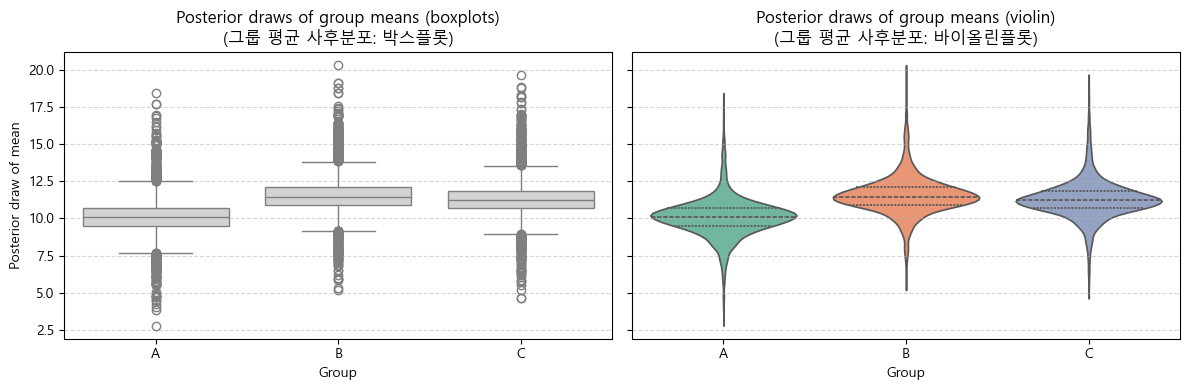

In [28]:
# (추가) Posterior group means: boxplot vs violin plot (1×2)
required_plot = ['mu_post', 'groups_sorted']
missing_plot = [name for name in required_plot if name not in globals()]
if missing_plot:
    raise RuntimeError(f"Missing variables for posterior mean plots: {missing_plot}. Run the Bayesian ANOVA sampling cell first.")

# Long-form dataframe for seaborn
mu_long = (
    mu_post[groups_sorted]
    .copy()
    .assign(draw=np.arange(len(mu_post)))
    .melt(id_vars='draw', var_name='Group', value_name='mu')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left: box plots
sns.boxplot(data=mu_long, x='Group', y='mu', ax=axes[0], color='lightgray')
axes[0].set_title('Posterior draws of group means (boxplots)\n(그룹 평균 사후분포: 박스플롯)')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Posterior draw of mean')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Right: violin plots (Seaborn v0.14+ compatible: palette requires hue)
sns.violinplot(
    data=mu_long,
    x='Group',
    y='mu',
    hue='Group',
    legend=False,
    dodge=False,
    inner='quartile',
    cut=0,
    palette='Set2',
    ax=axes[1],
)
axes[1].set_title('Posterior draws of group means (violin)\n(그룹 평균 사후분포: 바이올린플롯)')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

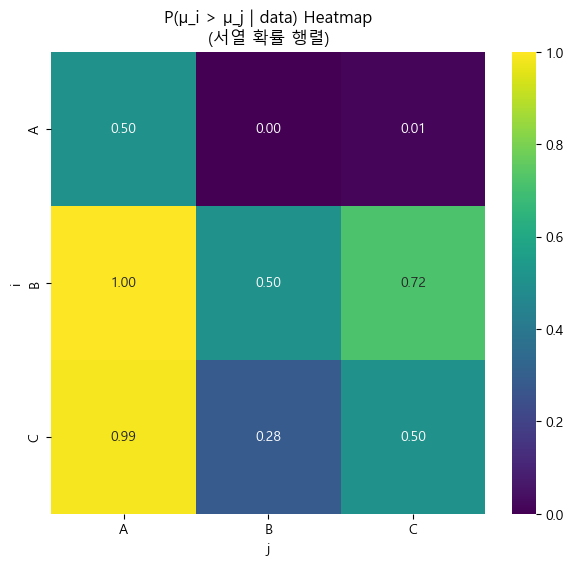

In [21]:
# 1) Ordering probabilities: P(μ_i > μ_j | data) heatmap (서열 확률 행렬)
P_gt = pd.DataFrame(index=groups_sorted, columns=groups_sorted, dtype=float)
for gi in groups_sorted:
    for gj in groups_sorted:
        if gi == gj:
            P_gt.loc[gi, gj] = 0.5
        else:
            P_gt.loc[gi, gj] = (mu_post[gi].to_numpy() > mu_post[gj].to_numpy()).mean()

plt.figure(figsize=(7, 6))
sns.heatmap(P_gt.astype(float), annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1)
plt.title('P(μ_i > μ_j | data) Heatmap\n(서열 확률 행렬)')
plt.xlabel('j')
plt.ylabel('i')
plt.show()

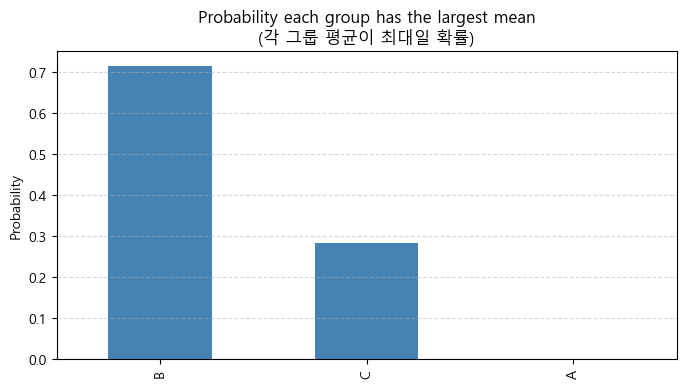

=== Ordering probabilities ===
P(group is the largest mean):
- B: 0.715
- C: 0.284
- A: 0.001


In [22]:
# 2) Probability each group has the largest mean (각 그룹 평균이 최대일 확률)
mu_arr = mu_post[groups_sorted].to_numpy()  # shape: (S, K)
argmax = np.argmax(mu_arr, axis=1)
prob_top = pd.Series(np.bincount(argmax, minlength=K) / len(argmax), index=groups_sorted)

plt.figure(figsize=(8, 4))
prob_top.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Probability each group has the largest mean\n(각 그룹 평균이 최대일 확률)')
plt.ylabel('Probability')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

print('=== Ordering probabilities ===')
print('P(group is the largest mean):')
for gname, p in prob_top.sort_values(ascending=False).items():
    print(f"- {gname}: {p:.3f}")

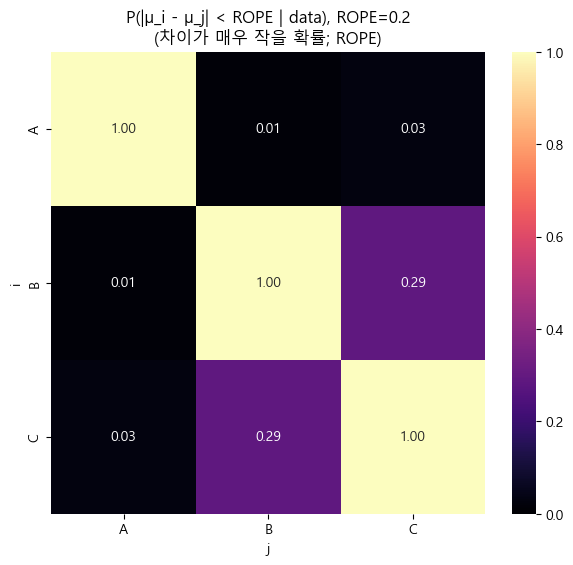

In [23]:
# 3) ROPE probabilities for pairwise differences (실질적 동등성; ROPE)
# NOTE: ROPE width is context-dependent; here we pick 0.2 as an example on the score scale.
rope = 0.2

rope_mat = pd.DataFrame(index=groups_sorted, columns=groups_sorted, dtype=float)
for gi in groups_sorted:
    for gj in groups_sorted:
        if gi == gj:
            rope_mat.loc[gi, gj] = 1.0
        else:
            diff = (mu_post[gi] - mu_post[gj]).to_numpy()
            rope_mat.loc[gi, gj] = (np.abs(diff) < rope).mean()

plt.figure(figsize=(7, 6))
sns.heatmap(rope_mat.astype(float), annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1)
plt.title(f'P(|μ_i - μ_j| < ROPE | data), ROPE={rope}\n(차이가 매우 작을 확률; ROPE)')
plt.xlabel('j')
plt.ylabel('i')
plt.show()

### ICC의 목적은 무엇인가? (What is the purpose of ICC here?)

베이지안 일원 ANOVA를 **계층모형(random intercept)**으로 보면, 관측치의 변동은 크게 두 부분으로 나뉩니다.
(In a hierarchical/random-intercept view of one-way ANOVA, variability decomposes into two parts.)

- **집단 내 변동 (within-group)**: 같은 그룹 안에서 개인 점수들이 흔들리는 정도 → $\sigma$
- **집단 간 변동 (between-group)**: 그룹 평균 자체가 서로 얼마나 다른지 → $\tau$

이때 **ICC (Intraclass Correlation Coefficient)**를
$$\mathrm{ICC} = \frac{\tau^2}{\tau^2+\sigma^2}$$
로 정의하면, **전체 변동 중에서 “집단 간 차이”가 차지하는 비율**을 한 숫자로 요약할 수 있습니다.
So ICC summarizes the **proportion of total variance attributable to between-group differences**.

- ICC가 **0에 가까우면**: 그룹 간 차이는 작고, 대부분의 변동은 그룹 내부(개인차/오차)에서 옴.
- ICC가 **1에 가까우면**: 그룹 간 평균 차이가 크고, 관측치 변동의 상당 부분이 그룹 차이로 설명됨.

즉, ANOVA의 “차이가 있다/없다”를 넘어서 **효과의 구조(variance decomposition)**를 해석하는 데 유용합니다.

---

### 예시 해석: 사후평균 ICC = 0.377 (How to read ICC = 0.377?)

- **해석(variance share)**: 이 모형 관점에서 전체 변동의 약 **37.7%**가 “집단 간 차이(그룹 평균 차이)”에 해당하고, 나머지 약 **62.3%**는 “집단 내 변동(개인차/오차)”입니다.
  - In words: about **37.7%** of the total variance is attributable to **between-group differences**, and about **62.3%** to **within-group variability**.
- **의미(what it implies)**: 그룹 효과가 0에 가깝지는 않지만(그룹 차이가 어느 정도 존재), 관측치 변동의 더 큰 부분은 여전히 그룹 내부에서 옵니다.
  - This suggests a **moderate** degree of clustering/stratification by group, not an overwhelming separation.

> 권장: ICC는 점추정(사후평균)만 보지 말고, 같은 셀에서 출력되는 **$96\%$ HDI**까지 함께 보고 “불확실성(credible range)”도 같이 해석하세요.
  Recommended: interpret ICC together with its **$96\%$ HDI** to reflect posterior uncertainty.

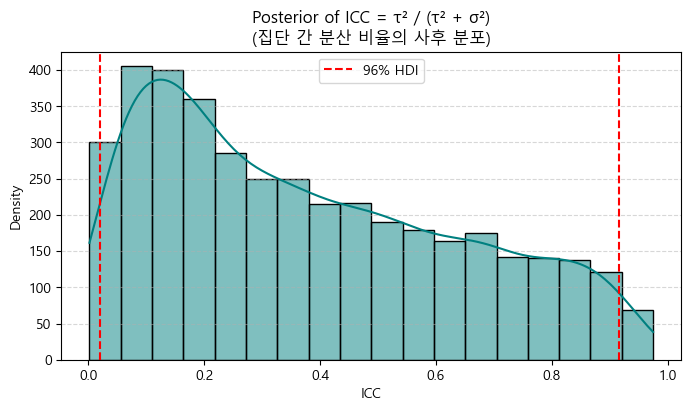

=== Variance components ===
Posterior mean sigma (within SD): 1.972
Posterior mean tau   (between SD): 1.818
Posterior mean ICC: 0.377, 96% HDI=[0.021, 0.915]


In [24]:
# 4) Variance components + ICC (분산 성분 + ICC)
# ICC = τ² / (τ² + σ²): proportion of variance attributable to between-group differences.
sigma = sigma_post.to_numpy()
tau = tau_post.to_numpy()
icc = (tau ** 2) / (tau ** 2 + sigma ** 2)

lo_icc, hi_icc = hdi(icc, prob=hdi_prob)

plt.figure(figsize=(8, 4))
sns.histplot(icc, kde=True, color='teal')
plt.axvline(lo_icc, color='red', linestyle='--', label=f'{int(hdi_prob*100)}% HDI')
plt.axvline(hi_icc, color='red', linestyle='--')
plt.title('Posterior of ICC = τ² / (τ² + σ²)\n(집단 간 분산 비율의 사후 분포)')
plt.xlabel('ICC')
plt.ylabel('Density')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print('=== Variance components ===')
print(f"Posterior mean sigma (within SD): {sigma.mean():.3f}")
print(f"Posterior mean tau   (between SD): {tau.mean():.3f}")
print(f"Posterior mean ICC: {icc.mean():.3f}, {int(hdi_prob*100)}% HDI=[{lo_icc:.3f}, {hi_icc:.3f}]")

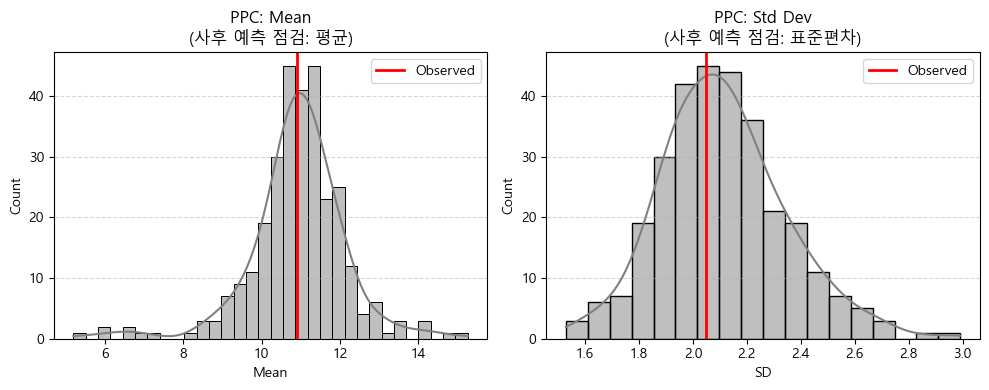

=== PPC quick check ===
Observed mean=10.918; Posterior predictive P(mean_rep >= mean_obs)=0.513
(If this is near 0 or 1, the model may not reproduce the observed mean well.)


In [25]:
# 5) Posterior Predictive Check (PPC; 사후 예측 점검)
# Simple PPC: simulate replicated observations using mu_post and sigma_post and compare mean/SD.
S = len(mu_post)
rng = np.random.default_rng(42)

# Use a subset of posterior draws for speed
S_sub = min(300, S)
idx = rng.choice(S, size=S_sub, replace=False)

# Observed summaries
obs_mean = y.mean()     # 
obs_sd = y.std(ddof=1)

rep_means = np.empty(S_sub)
rep_sds = np.empty(S_sub)

# g is 1..K aligned with groups_sorted order
for t, s_idx in enumerate(idx):
    mu_draw = mu_post.iloc[s_idx].to_numpy()  # length K
    sigma_draw = float(sigma_post.iloc[s_idx])
    mu_for_obs = mu_draw[g - 1]
    y_rep = rng.normal(loc=mu_for_obs, scale=sigma_draw, size=len(y))
    rep_means[t] = y_rep.mean()
    rep_sds[t] = y_rep.std(ddof=1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(rep_means, kde=True, color='gray')
plt.axvline(obs_mean, color='red', linewidth=2, label='Observed')
plt.title('PPC: Mean\n(사후 예측 점검: 평균)')
plt.xlabel('Mean')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(rep_sds, kde=True, color='gray')
plt.axvline(obs_sd, color='red', linewidth=2, label='Observed')
plt.title('PPC: Std Dev\n(사후 예측 점검: 표준편차)')
plt.xlabel('SD')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

p_mean = (rep_means >= obs_mean).mean()
print('=== PPC quick check ===')
print(f"Observed mean={obs_mean:.3f}; Posterior predictive P(mean_rep >= mean_obs)={p_mean:.3f}")
print('(If this is near 0 or 1, the model may not reproduce the observed mean well.)')

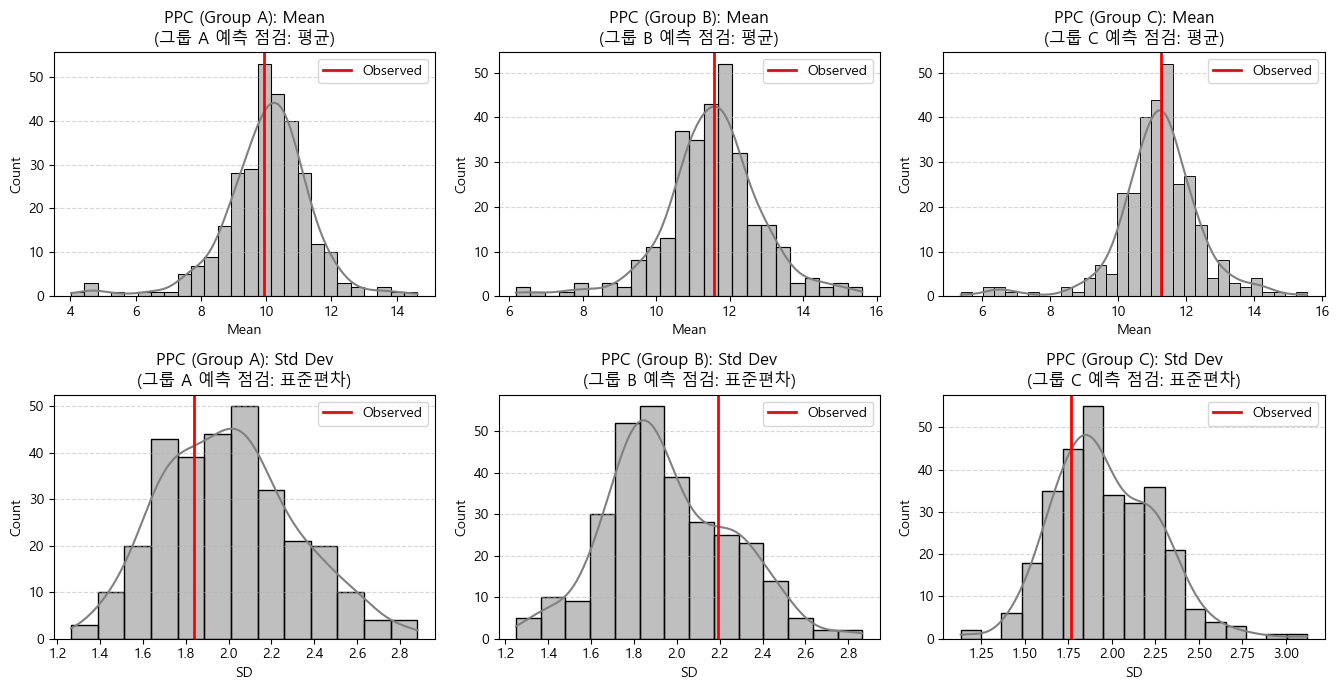

=== PPC by group (quick checks) ===
- Group A: obs_mean=9.919, P(mean_rep >= mean_obs)=0.573
           obs_sd  =1.841, P(sd_rep   >= sd_obs)  =0.667
- Group B: obs_mean=11.567, P(mean_rep >= mean_obs)=0.497
           obs_sd  =2.192, P(sd_rep   >= sd_obs)  =0.230
- Group C: obs_mean=11.268, P(mean_rep >= mean_obs)=0.497
           obs_sd  =1.764, P(sd_rep   >= sd_obs)  =0.747
(As with the grand-mean PPC, values near 0 or 1 can indicate mismatch.)


In [26]:
# 6) PPC by group (그룹별 사후 예측 점검)
required_ppc = ['mu_post', 'sigma_post', 'groups_sorted', 'g', 'y']
missing_ppc = [name for name in required_ppc if name not in globals()]
if missing_ppc:
    raise RuntimeError(f"Missing variables for PPC by group: {missing_ppc}. Run the Bayesian ANOVA cells first.")

groups_sorted = list(groups_sorted)
K = len(groups_sorted)
S = len(mu_post)
rng = np.random.default_rng(42)

# Use a subset of posterior draws for speed
S_sub = min(300, S)
idx = rng.choice(S, size=S_sub, replace=False)

# Observed group summaries
obs_mean_by_group = np.array([y[g == (k + 1)].mean() for k in range(K)])
obs_sd_by_group = np.array([y[g == (k + 1)].std(ddof=1) for k in range(K)])

rep_means_by_group = np.empty((S_sub, K))
rep_sds_by_group = np.empty((S_sub, K))

for t, s_idx in enumerate(idx):
    mu_draw = mu_post.iloc[s_idx].to_numpy()  # length K
    sigma_draw = float(sigma_post.iloc[s_idx])
    mu_for_obs = mu_draw[g - 1]
    y_rep = rng.normal(loc=mu_for_obs, scale=sigma_draw, size=len(y))
    for k in range(K):
        yk = y_rep[g == (k + 1)]
        rep_means_by_group[t, k] = yk.mean()
        rep_sds_by_group[t, k] = yk.std(ddof=1)

# Plot: group-wise means and SDs (2 x K panels)
fig, axes = plt.subplots(2, K, figsize=(4.5 * K, 7), sharey=False)
for k, gname in enumerate(groups_sorted):
    ax = axes[0, k] if K > 1 else axes[0]
    sns.histplot(rep_means_by_group[:, k], kde=True, color='gray', ax=ax)
    ax.axvline(obs_mean_by_group[k], color='red', linewidth=2, label='Observed')
    ax.set_title(f'PPC (Group {gname}): Mean\n(그룹 {gname} 예측 점검: 평균)')
    ax.set_xlabel('Mean')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend()

    ax = axes[1, k] if K > 1 else axes[1]
    sns.histplot(rep_sds_by_group[:, k], kde=True, color='gray', ax=ax)
    ax.axvline(obs_sd_by_group[k], color='red', linewidth=2, label='Observed')
    ax.set_title(f'PPC (Group {gname}): Std Dev\n(그룹 {gname} 예측 점검: 표준편차)')
    ax.set_xlabel('SD')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

print('=== PPC by group (quick checks) ===')
for k, gname in enumerate(groups_sorted):
    p_mean_k = (rep_means_by_group[:, k] >= obs_mean_by_group[k]).mean()
    p_sd_k = (rep_sds_by_group[:, k] >= obs_sd_by_group[k]).mean()
    print(f"- Group {gname}: obs_mean={obs_mean_by_group[k]:.3f}, P(mean_rep >= mean_obs)={p_mean_k:.3f}")
    print(f"           obs_sd  ={obs_sd_by_group[k]:.3f}, P(sd_rep   >= sd_obs)  ={p_sd_k:.3f}")
print('(As with the grand-mean PPC, values near 0 or 1 can indicate mismatch.)')

## ANOVA 종류 요약표 (ANOVA Cheat Sheet)

아래 표는 대표적인 ANOVA/관련 분석들을 “언제 쓰는가(목적)”와 “핵심 개념(무엇을 분해/비교하는가)” 관점에서 정리한 것입니다.
The table below summarizes common ANOVA variants by **purpose** and **core concept** (what variance/effects are being decomposed/tested).

| 분석 (Analysis) | 목적 (Purpose) | 핵심 개념 / 모델 아이디어 (Main concept) | 예시 질문 (Example question) |
|---|---|---|---|
| **일원 ANOVA** (One-way ANOVA) | 한 개 요인(집단) 수준들 간 평균 차이 비교 | 총 변동을 **집단 간** vs **집단 내**로 분해; $y \sim \mu_{group}+\epsilon$ | “A,B,C 평균이 같은가?” |
| **이원 ANOVA** (Two-way / Factorial ANOVA) | 두 요인의 **주효과(main effects)**와 **상호작용(interaction)** 평가 | 변동을 요인 A, 요인 B, A×B, 오차로 분해 | “훈련(유/무) 효과가 성별에 따라 달라지나?” |
| **반복측정 ANOVA** (Repeated-measures ANOVA) | 같은 참가자를 여러 조건/시간에서 반복 측정한 평균 차이 | 개인(피험자) 효과를 분리해 오차를 줄임; sphericity 가정 | “시간에 따라 점수가 변하나?” |
| **혼합 ANOVA** (Mixed / Split-plot ANOVA) | between 요인 + within 요인이 함께 있을 때 | 참가자 랜덤효과 + 요인(및 상호작용) | “집단(A/B) × 시간(전/후) 상호작용?” |
| **Welch ANOVA** | 등분산 가정이 깨졌을 때(집단 분산이 다를 때) 평균 비교 | 등분산 대신 가중/자유도 보정으로 더 견고 | “분산이 다른 3집단 평균 비교” |
| **ANCOVA** | 집단 평균 비교 + 공변량(covariate) 보정 | 회귀 + ANOVA: $y \sim group + x + \epsilon$ | “사전점수 통제 후 집단차?” |
| **MANOVA** | 종속변수가 여러 개인 경우(벡터 평균 비교) | 평균 벡터 차이를 공분산 구조와 함께 평가 | “(수학,읽기) 점수에서 집단 차이?” |
| **MANCOVA** | MANOVA + 공변량 보정 | 다변량 + 공변량 조정 | “IQ 통제 후 (수학,읽기) 집단차?” |
| **공분산/혼합효과 모형** (LMM/GLMM; 확장) | 불균형 설계/결측/복잡한 랜덤구조(학교-학급-학생 등) | ANOVA를 **계층모형**으로 일반화(부분 풀링, 랜덤효과) | “학교/학급 효과까지 포함하면?” |

> 메모 (Note): 위 표의 대부분은 빈도주의/베이지안 모두에서 ‘같은 구조’를 갖되, 베이지안은 보통 p-value 대신 **사후분포(credible intervals, probability statements)**로 요약합니다.